In [24]:
import numpy as np
import subprocess

current_numpy = np.__version__
subprocess.run(f"pip install caustics astropy h5py numpy=={current_numpy}", shell=True)

Using device: cuda


In [25]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import h5py
import urllib.request
import os
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [46]:
BATCH_SIZE = 64
SEED = 42
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5
LAMBDA = 0.5

In [4]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

## Load Real Galaxy Data

In [5]:
# !wget https://astro.utoronto.ca/~hleung/shared/Galaxy10/Galaxy10_DECals.h5 -O Galaxy10_DECals.h5 --no-check-certificate

In [6]:
# !pip install lenstronomy pyHalo colossus mcfit astropy -q

In [7]:
# import random
# from scipy.ndimage import gaussian_filter
# from lenstronomy.SimulationAPI.sim_api import SimAPI
# from lenstronomy.SimulationAPI.ObservationConfig.Euclid import Euclid
# from astropy.cosmology import FlatLambdaCDM
# from pyHalo.PresetModels.uldm import ULDM
# from pyHalo.PresetModels.cdm import CDM

# classes = ['no', 'sphere', 'vort']
# for c in classes:
#     os.makedirs(f'train/{c}', exist_ok=True)
#     os.makedirs(f'val/{c}', exist_ok=True)

# cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Ob0=0.)
# Euclid_v = Euclid(band='VIS', psf_type='GAUSSIAN', coadd_years=6)
# kwargs_v_band = Euclid_v.kwargs_single_band()

# def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
#     return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

# x = np.linspace(-128, 128, 256)
# y = np.linspace(-128, 128, 256)
# xx, yy = np.meshgrid(x, y)
# gaussian_mask = gaus2d(x=xx, y=yy, mx=0, my=0, sx=25, sy=25)

In [8]:
# def simulate_substructure(image_galaxy, class_type):
#     Ens = np.random.normal(1.5, 0.5)
#     zlens, zsource = 0.5, 1.0
    
#     kwargs_lens_main = {'theta_E': Ens, 'e1': 0, 'e2': 0, 'center_x': 0, 'center_y': 0.}
#     kwargs_shear = {'gamma1': 0.05, 'gamma2': 0}
#     lens_model_list = ['SIE', 'SHEAR']
#     lens_redshift_list = [zlens, zlens]
#     kwargs_lens = [kwargs_lens_main, kwargs_shear]
#     astropy_instance = cosmo

#     if class_type == 'sphere':
#         realizationsCDM = CDM(zlens, zsource, cone_opening_angle_arcsec=10)
#         halos_model_list, halos_redshift_array, kwargs_halos, _ = realizationsCDM.lensing_quantities()
#         lens_model_list += halos_model_list
#         lens_redshift_list += list(halos_redshift_array)
#         kwargs_lens += kwargs_halos
#         astropy_instance = realizationsCDM.astropy_instance
        
#     elif class_type == 'vort':
#         realizationsULDM = ULDM(zlens, zsource, log10_m_uldm=-21.5, uldm_plaw=1/3, flucs=False)
#         halos_model_list, halos_redshift_array, kwargs_halos, _ = realizationsULDM.lensing_quantities()
#         lens_model_list += halos_model_list
#         lens_redshift_list += list(halos_redshift_array)
#         kwargs_lens += kwargs_halos
#         astropy_instance = realizationsULDM.astropy_instance

#     kwargs_model_physical = {
#         'lens_model_list': lens_model_list,
#         'lens_redshift_list': lens_redshift_list,
#         'lens_light_model_list': ['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE'],
#         'source_light_model_list': ['INTERPOL'],
#         'source_redshift_list': [1.0],
#         'cosmo': astropy_instance,
#         'z_source_convention': 2.5,
#         'z_source': 2.5,
#     }

#     sim = SimAPI(numpix=64, kwargs_single_band=kwargs_v_band, kwargs_model=kwargs_model_physical)
#     imSim = sim.image_model_class({'point_source_supersampling_factor': 1})

#     source_scale = 0.005
#     img_vis = image_galaxy[:, :, 0].astype(float) # VIS band
#     smoothed = gaussian_filter(img_vis, sigma=3)
#     masked_galaxy = gaussian_mask * smoothed
#     masked_galaxy -= np.median(masked_galaxy[:50, :50])

#     X, Y = np.random.uniform(-0.4, 0.4, 2)
#     source_ang = np.random.uniform(-np.pi, np.pi)

#     kwargs_lens_light_mag = [
#         {'magnitude': 40, 'R_sersic': 0.4, 'n_sersic': 2.3, 'e1': 0, 'e2': 0.05, 'center_x': 0, 'center_y': 0},
#         {'magnitude': 40, 'R_sersic': 1.5, 'n_sersic': 1.2, 'e1': 0, 'e2': 0.3, 'center_x': 0, 'center_y': 0}
#     ]
#     kwargs_source_mag = [{'magnitude': np.random.normal(16, 0.1), 'image': masked_galaxy, 'scale': source_scale, 'phi_G': source_ang, 'center_x': X, 'center_y': Y}]

#     kwargs_lens_light, kwargs_source, _ = sim.magnitude2amplitude(kwargs_lens_light_mag, kwargs_source_mag)
    
#     image_no_noise = imSim.image(kwargs_lens, kwargs_source, kwargs_lens_light)
#     final_image = image_no_noise + sim.noise_for_model(model=image_no_noise)
    
#     final_image = np.absolute(final_image).clip(min=0)
#     if np.max(final_image) > 0:
#         final_image /= np.max(final_image)
        
#     return final_image

## Simulate Substructures on Real Galaxy

In [9]:
# print("Loading Real Galaxies...")
# with h5py.File('Galaxy10_DECals.h5', 'r') as F:
#     images = np.array(F['images'])
#     typ, z = np.array(F['ans']), np.array(F['redshift'])

# unbarred_spiral = np.where(typ == 6)
# img_zp1 = images[unbarred_spiral][np.where(z[unbarred_spiral] < 0.02)]
# arr = [2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,31,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,54,55]
# golden_galaxies = img_zp1[arr]

# num_per_class = 200

# for c in classes:
#     print(f"\nGenerating {c.upper()} Class...")
#     for i in tqdm(range(num_per_class)):
#         galaxy = random.choice(golden_galaxies)
#         sim_img = simulate_substructure(galaxy, class_type=c)
#         folder = 'val' if i < 20 else 'train'
#         np.save(f"{folder}/{c}/sim_{random.getrandbits(64)}.npy", sim_img, allow_pickle=True)


# !zip -q -r dataset_model_iv.zip train/ val/
# print("\nDataset generated and saved as dataset_model_iv.zip")

In [10]:
root_data_dir = Path('/kaggle/input/datasets/aditibindal/real-galaxy-simulations-model-iv/')
no_1 = np.load(root_data_dir/'train/no/sim_1006398708239564861.npy')
no_1.shape

(64, 64)

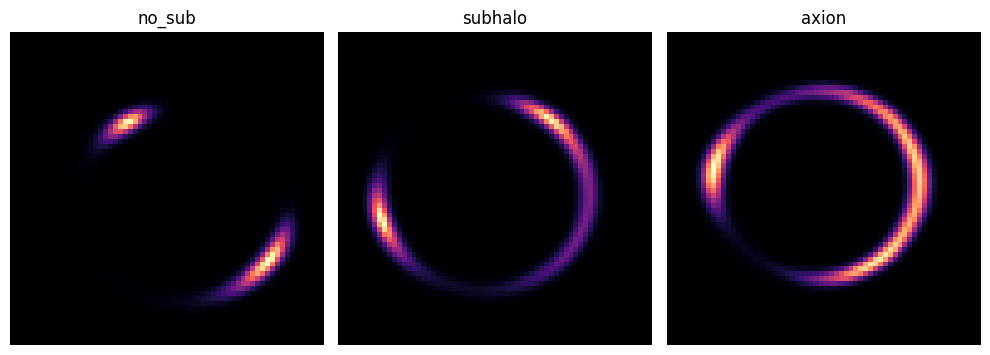

In [11]:
no = np.load(root_data_dir/'train/no/sim_1006398708239564861.npy')
subhalo = np.load(root_data_dir/'train/sphere/sim_10039532192349557595.npy')
axion = np.load(root_data_dir/'train/vort/sim_10142376546592722325.npy')

def plot_train_samples(samples_dict):
    plt.figure(figsize=(10, 4))
    
    for i, (label, img) in enumerate(samples_dict.items()):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img, cmap="magma")
        plt.title(label)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

samples = {
    "no_sub": no,
    "subhalo": subhalo,
    "axion": axion,
}

plot_train_samples(samples)

## Dataset Object and Loader

In [12]:
root_data_dir = Path("/kaggle/input/datasets/aditibindal/real-galaxy-simulations-model-iv/")

In [13]:
from torch.utils.data import Dataset, DataLoader, random_split

class DeepLenseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort'] 
        self.filepaths = []
        self.labels = []
        
        for label_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(self.root_dir, class_name)
            if os.path.exists(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith('.npy'):
                        self.filepaths.append(os.path.join(class_dir, file))
                        self.labels.append(label_idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, i):
        img_path = self.filepaths[i]
        image = np.load(img_path) 
        
        if image.ndim == 2:
            image = np.expand_dims(image, axis=0)
            
        image = torch.tensor(image, dtype=torch.float32)
        
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        label = self.labels[i]

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
def create_transform_pipelines():
    IMAGENET_MEAN = [0.485, 0.456, 0.406] 
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # standard transformations (resize, center, rotate, normalize)
    train_transforms = transforms.Compose([
        transforms.Resize(256, antialias=True), 
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    test_transforms = transforms.Compose([
        transforms.Resize(256, antialias=True),
        transforms.CenterCrop(224),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    return train_transforms, test_transforms
    
train_transform, test_transform = create_transform_pipelines()

In [15]:
from torch.utils.data import DataLoader, random_split, Subset

def create_datasets_and_dataloaders(data_dir,
                                  train_transform,
                                  test_transform,
                                  batch_size = 64,
                                  num_workers = 0) -> tuple:

    full_train_dataset = DeepLenseDataset(root_dir=data_dir/"train", transform=train_transform)
    val_base_dataset = DeepLenseDataset(root_dir=data_dir/"train", transform=test_transform)
    
    test_dataset = DeepLenseDataset(root_dir=data_dir/"val", transform=test_transform)

    class_names = full_train_dataset.classes
    
    num_images = len(full_train_dataset)
    train_size = int(0.9 * num_images)
    val_size = num_images - train_size
    
    train_idx, val_idx = random_split(
        range(num_images), 
        [train_size, val_size], 
        generator=torch.Generator().manual_seed(42)
    )
    
    train_subset = Subset(full_train_dataset, train_idx)
    val_subset = Subset(val_base_dataset, val_idx)
    
    train_dataloader = DataLoader(dataset=train_subset,
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=num_workers,
                                  pin_memory=True if torch.cuda.is_available() else False)

    val_dataloader = DataLoader(dataset=val_subset,
                                 batch_size=batch_size,
                                 shuffle=False,
                                 num_workers=num_workers,
                                 pin_memory=True if torch.cuda.is_available() else False)

    test_dataloader = DataLoader(dataset=test_dataset,
                                 batch_size=batch_size,
                                 shuffle=False,
                                 num_workers=num_workers,
                                 pin_memory=True if torch.cuda.is_available() else False)

    return train_subset, val_subset, test_dataset, train_dataloader, val_dataloader, test_dataloader, class_names

train_subset, val_subset, test_dataset, train_dataloader, val_dataloader, test_dataloader, class_names = create_datasets_and_dataloaders(
    data_dir=root_data_dir,
    train_transform=train_transform,
    test_transform=test_transform,
    batch_size=BATCH_SIZE,
    num_workers=0
)

print("=== DATASET AND DATALOADER SUMMARY ===")
print(f"Training samples (90%): {len(train_subset)}")
print(f"Validation samples (10%): {len(val_subset)}")
print(f"Test samples (Unseen): {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")

=== DATASET AND DATALOADER SUMMARY ===
Training samples (90%): 486
Validation samples (10%): 54
Test samples (Unseen): 60
Number of classes: 3


## Load trained ResNet34 & AuxPINN weights

In [16]:
loss_fn = nn.CrossEntropyLoss()

In [18]:
resnet34_model = models.resnet34(weights=None)
num_feat = resnet34_model.fc.in_features
resnet34_model.fc = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=num_feat, out_features=3, bias=True)
)
resnet34_model = resnet34_model.to(device)

resnet34_state_dict = torch.load('/kaggle/input/models/aditibindal/resnet34-classification/pytorch/default/1/best_classification_resnet34_model.pth', map_location=device)
processed_resnet34_dict = {k.replace('_orig_mod.', ''): v for k, v in resnet34_state_dict.items()}

resnet34_model.load_state_dict(processed_resnet34_dict)
print("Common ResNet34 weights loaded successfully.")

Common ResNet34 weights loaded successfully.


In [19]:
criterion_head1 = nn.MSELoss()
criterion_head2 = nn.CrossEntropyLoss()

In [20]:
class AuxPINN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet34(weights=None) 
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        self.head1 = nn.Linear(512, 1)
        torch.nn.init.zeros_(self.head1.weight)
        torch.nn.init.zeros_(self.head1.bias)
        
        self.head2 = nn.Linear(512 + 1, 3)
        
    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)
        
        predicted_radius = torch.sigmoid(self.head1(features)) * 3.0
        combined_features = torch.cat((features, predicted_radius), dim=1)
        
        class_logits = self.head2(combined_features)
        return class_logits, predicted_radius

aux_pinn_model = AuxPINN().to(device)

aux_state_dict = torch.load('/kaggle/input/models/aditibindal/auxiliary-pinn-classification/pytorch/default/1/best_aux_pinn_model.pth', map_location=device)
clean_aux_dict = {k.replace('_orig_mod.', ''): v for k, v in aux_state_dict.items()}
aux_pinn_model.load_state_dict(clean_aux_dict)
print("AuxPINN weights loaded successfully.")

AuxPINN weights loaded successfully.


In [21]:
resnet34_model.eval()
aux_pinn_model.eval()

print("Both models ready for inference.")

Both models ready for inference.


## Zero Shot Transfer

In [22]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

def evaluate_model(model, test_dataloader, criterion, device, is_pinn=False, model_name="Model"):
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], [] 
    
    test_pbar = tqdm(test_dataloader, desc=f'Evaluating {model_name}')
    with torch.no_grad():
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            if is_pinn:
                outputs, predicted_radius = model(inputs)
            else:
                outputs = model(inputs)
                
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            probs = torch.nn.functional.softmax(outputs, dim=1)  
            _, predicted = torch.max(outputs, 1)
            
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  
            
            test_pbar.set_postfix({'loss': loss.item(), 'acc': test_correct/test_total})
    
    test_loss = test_loss / len(test_dataloader.dataset)
    test_acc = test_correct / test_total
    
    cm = confusion_matrix(all_labels, all_preds)
    all_labels_np, all_probs_np = np.array(all_labels), np.array(all_probs)
    n_classes = all_probs_np.shape[1]
    fpr, tpr, roc_auc = {}, {}, {}
    
    for i in range(n_classes):
        binary_labels = (all_labels_np == i).astype(int)
        class_probs = all_probs_np[:, i]
        fpr[i], tpr[i], _ = roc_curve(binary_labels, class_probs)
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    macro_roc_auc = sum(roc_auc.values()) / n_classes
    print(f'{model_name} -> Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Macro-AUC: {macro_roc_auc:.4f}')
    
    return test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc


--- Evaluating ResNet ---


Evaluating ResNet-18:   0%|          | 0/1 [00:00<?, ?it/s]

ResNet-18 -> Test Loss: 5.5274, Test Acc: 0.3333, Macro-AUC: 0.4496

--- Evaluating Aux-PINN ---


Evaluating Aux-PINN:   0%|          | 0/1 [00:00<?, ?it/s]

Aux-PINN -> Test Loss: 2.1745, Test Acc: 0.2667, Macro-AUC: 0.5200

Generating Comparison Charts...


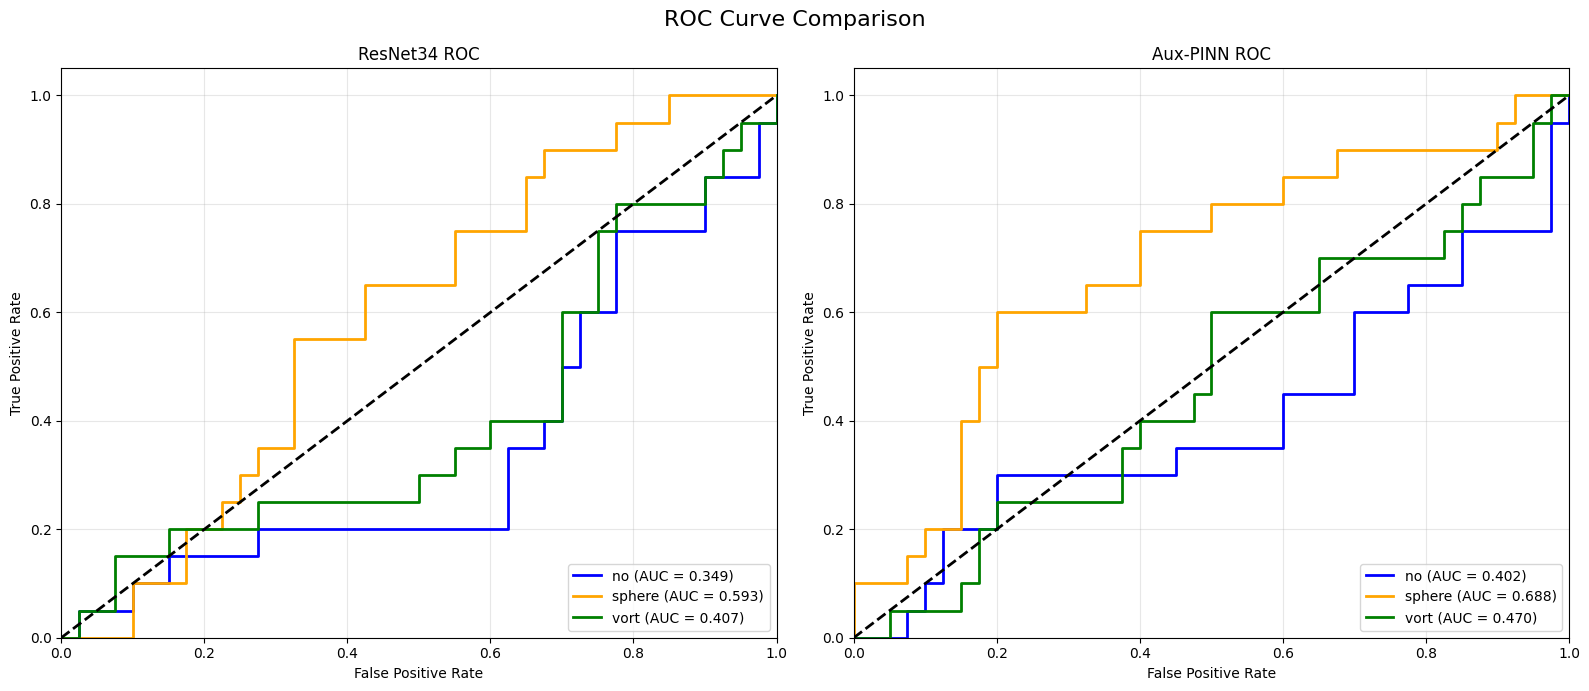

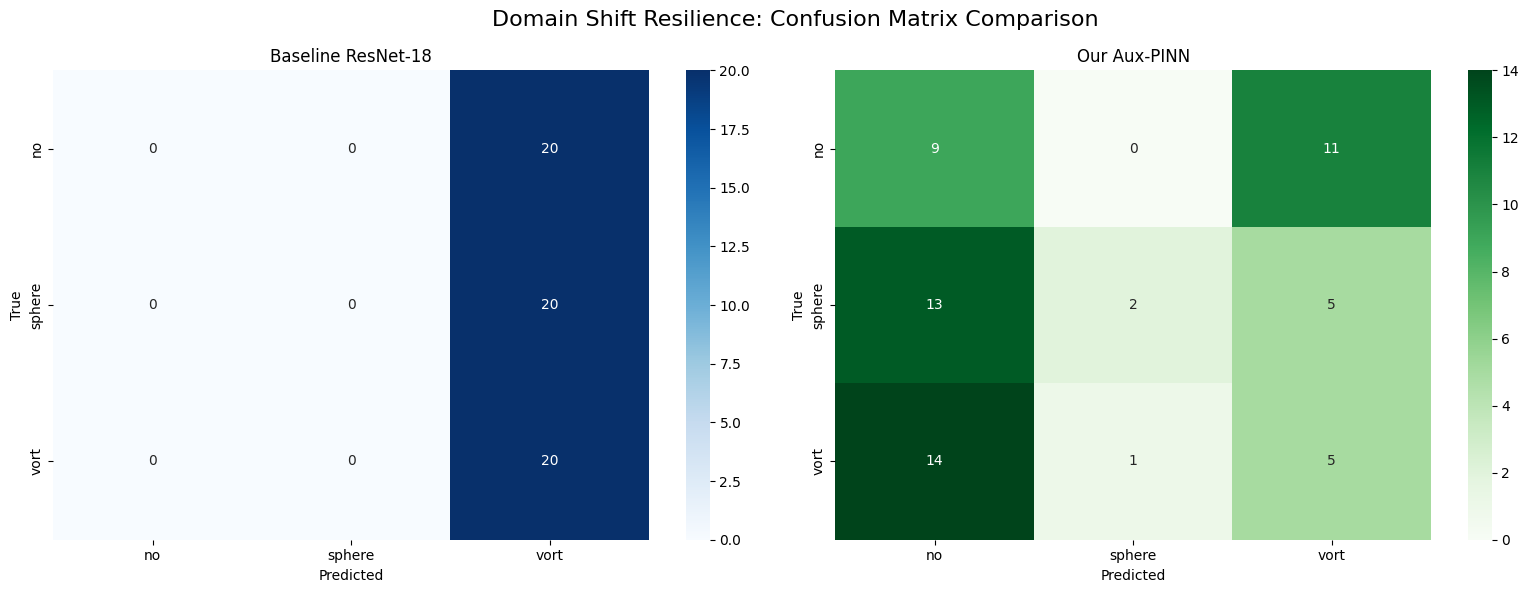

In [27]:
def plot_roc_curves_comparison(res_fpr, res_tpr, res_auc, pinn_fpr, pinn_tpr, pinn_auc, class_names, save_path='comparison_roc.png'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    colors = ['blue', 'orange', 'green']
    
    for i in range(len(class_names)):
        axes[0].plot(res_fpr[i], res_tpr[i], lw=2, color=colors[i],
                 label=f'{class_names[i]} (AUC = {res_auc[i]:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ResNet34 ROC')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # Plot Aux-PINN ROC
    for i in range(len(class_names)):
        axes[1].plot(pinn_fpr[i], pinn_tpr[i], lw=2, color=colors[i],
                 label=f'{class_names[i]} (AUC = {pinn_auc[i]:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Aux-PINN ROC')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle("ROC Curve Comparison", fontsize=16)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix_comparison(res_cm, pinn_cm, class_names, save_path='comparison_cm.png'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(res_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Baseline ResNet-18')
    
    sns.heatmap(pinn_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Our Aux-PINN')
    
    plt.suptitle("Domain Shift Resilience: Confusion Matrix Comparison", fontsize=16)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


print("\n--- Evaluating ResNet ---")
res_loss, res_acc, res_cm, _, _, _, res_fpr, res_tpr, res_roc_auc, res_macro_auc = evaluate_model(
    model=resnet34_model,
    test_dataloader=test_dataloader,
    criterion=loss_fn,
    device=device,
    is_pinn=False,
    model_name="ResNet-18"
)

print("\n--- Evaluating Aux-PINN ---")
pinn_loss, pinn_acc, pinn_cm, _, _, _, pinn_fpr, pinn_tpr, pinn_roc_auc, pinn_macro_auc = evaluate_model(
    model=aux_pinn_model, 
    test_dataloader=test_dataloader,
    criterion=criterion_head2,
    device=device,
    is_pinn=True,
    model_name="Aux-PINN"
)

print("\nGenerating Comparison Charts...")
plot_roc_curves_comparison(
    res_fpr, res_tpr, res_roc_auc, 
    pinn_fpr, pinn_tpr, pinn_roc_auc, 
    class_names, save_path='aux_vs_resnet_roc_comparison.png'
)

plot_confusion_matrix_comparison(
    res_cm, pinn_cm, class_names, save_path='aux_vs_resnet_cm_comparison.png'
)

## Brief Target Domain Adaptation (Proof of Concept)

In [28]:
import caustics

In [29]:
cosmology = caustics.FlatLambdaCDM(name="cosmo")

lens = caustics.SIS(cosmology=cosmology, name="lens", z_l=0.5, z_s=1.0, x0=0.0, y0=0.0, Rein=None)
source = caustics.Sersic(name="source", x0=0.0, y0=0.0, q=0.5, phi=0.0, n=1.0, Re=1.0, Ie=10.0)

sim = caustics.LensSource(lens=lens, source=source, pixelscale=0.05, pixels_x=224, name="sim")
sim = sim.to(device)

print(f"Built 224x224 Differentiable physics simulator and moved to {device}")

Built 224x224 Differentiable physics simulator and moved to cuda


In [47]:
optimizer = torch.optim.Adam(aux_pinn_model.parameters(), lr=LEARNING_RATE)

In [49]:
import copy
import time

def train_pinn(model, train_dataloader, val_dataloader, optimizer, criterion_head1, criterion_head2, sim, device, epochs=10, lambda_weight=0.5):
    print("Starting AuxPINN Training...")
    print("-" * 70)
    
    start_time = time.time()
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    results = {
        'train_loss': [], 'train_class_loss': [], 'train_phys_loss': [], 'train_acc': [],
        'val_loss': [], 'val_class_loss': [], 'val_phys_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss, train_class_loss, train_phys_loss = 0.0, 0.0, 0.0
        train_acc, train_total = 0, 0
        
        train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            class_logits, predicted_radius = model(images)
            loss_class = criterion_head2(class_logits, labels)
            
            sim_fn = lambda r: sim({"lens": {"Rein": r}})
            simulated_images = torch.vmap(sim_fn)(predicted_radius.view(-1))
            real_images_1ch = images[:, 0, :, :] 
            loss_physics = criterion_head1(simulated_images.squeeze(), real_images_1ch)
            
            total_loss = loss_class + (lambda_weight * loss_physics)
            
            total_loss.backward()
            optimizer.step()
            
            train_loss += total_loss.item()
            train_class_loss += loss_class.item()
            train_phys_loss += loss_physics.item()
            _, preds = torch.max(class_logits, 1)
            train_acc += torch.sum(preds == labels.data).item()
            train_total += labels.size(0)

            train_bar.set_postfix({'loss': f"{total_loss.item():.4f}"})
    
        model.eval()
        val_loss, val_class_loss, val_phys_loss = 0.0, 0.0, 0.0
        val_acc, val_total = 0, 0
        val_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        
        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                
                class_logits, predicted_radius = model(images)
                loss_class = criterion_head2(class_logits, labels)
                
                sim_fn = lambda r: sim({"lens": {"Rein": r}})
                simulated_images = torch.vmap(sim_fn)(predicted_radius.view(-1))
                real_images_1ch = images[:, 0, :, :] 
                loss_physics = criterion_head1(simulated_images.squeeze(), real_images_1ch)
                
                total_loss = loss_class + (lambda_weight * loss_physics)
                
                val_loss += total_loss.item()
                val_class_loss += loss_class.item()
                val_phys_loss += loss_physics.item()
                _, preds = torch.max(class_logits, 1)
                val_acc += torch.sum(preds == labels.data).item()
                val_total += labels.size(0)

        train_acc /= train_total
        val_acc /= val_total

        results['train_loss'].append(train_loss / len(train_dataloader))
        results['train_class_loss'].append(train_class_loss / len(train_dataloader))
        results['train_phys_loss'].append(train_phys_loss / len(train_dataloader))
        results['train_acc'].append(train_acc)

        results['val_loss'].append(val_loss / len(val_dataloader))
        results['val_class_loss'].append(val_class_loss / len(val_dataloader))
        results['val_phys_loss'].append(val_phys_loss / len(val_dataloader))
        results['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d}/{epochs}")
        print(f"  TRAIN | Loss: {results['train_loss'][-1]:.4f} (Class: {results['train_class_loss'][-1]:.4f}, Phys: {results['train_phys_loss'][-1]:.4f}) | Acc: {results['train_acc'][-1]:.4f}")
        print(f"  VAL   | Loss: {results['val_loss'][-1]:.4f} (Class: {results['val_class_loss'][-1]:.4f}, Phys: {results['val_phys_loss'][-1]:.4f}) | Acc: {results['val_acc'][-1]:.4f}")
        print("-" * 70)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_aux_pinn_model.pth')
            print(f"New best model. Weights saved.")
        print("-" * 75)

    model.load_state_dict(best_model_wts)

    mins, secs = divmod(time.time() - start_time, 60)
    print(f"Training Complete in {int(mins)}m {int(secs)}s")
    return model, results

In [50]:
trained_auxpinn_model, results = train_pinn(
    model=aux_pinn_model, 
    train_dataloader=train_dataloader,  
    val_dataloader=val_dataloader,      
    optimizer=optimizer, 
    criterion_head1=criterion_head1, 
    criterion_head2=criterion_head2, 
    sim=sim, 
    device=device, 
    epochs=NUM_EPOCHS,
    lambda_weight=LAMBDA
)

Starting AuxPINN Training...
----------------------------------------------------------------------


Epoch 1/5 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch  1/5
  TRAIN | Loss: 8.1282 (Class: 1.8671, Phys: 12.5221) | Acc: 0.3477
  VAL   | Loss: 8.0810 (Class: 1.8276, Phys: 12.5067) | Acc: 0.2593
----------------------------------------------------------------------
New best model. Weights saved.
---------------------------------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch  4/5
  TRAIN | Loss: 7.5790 (Class: 1.3201, Phys: 12.5179) | Acc: 0.3930
  VAL   | Loss: 7.6820 (Class: 1.4287, Phys: 12.5066) | Acc: 0.2963
----------------------------------------------------------------------
New best model. Weights saved.
---------------------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch  5/5
  TRAIN | Loss: 7.4983 (Class: 1.2384, Phys: 12.5199) | Acc: 0.3909
  VAL   | Loss: 7.6513 (Class: 1.3980, Phys: 12.5066) | Acc: 0.2963
----------------------------------------------------------------------
---------------------------------------------------------------------------
Training Complete in 0m 25s


## Evaluation

In [39]:
def evaluate_pinn_model(model, test_dataloader, criterion, device):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    all_probs = [] 
    
    test_pbar = tqdm(test_dataloader, desc='Evaluating on test set')
    with torch.no_grad():
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs, predicted_radius = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            probs = torch.nn.functional.softmax(outputs, dim=1)  
            _, predicted = torch.max(outputs, 1)
            
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  
            
            test_pbar.set_postfix({'loss': loss.item(), 'acc': test_correct/test_total})
    
    test_loss = test_loss / len(test_dataloader.dataset)
    test_acc = test_correct / test_total
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    
    cm = confusion_matrix(all_labels, all_preds)
    
    all_labels_np = np.array(all_labels)
    all_probs_np = np.array(all_probs)
    
    n_classes = all_probs_np.shape[1]
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        binary_labels = (all_labels_np == i).astype(int)
        class_probs = all_probs_np[:, i]
        
        fpr[i], tpr[i], _ = roc_curve(binary_labels, class_probs)
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    macro_roc_auc = sum(roc_auc.values()) / n_classes
    print(f'Macro-averaged ROC AUC: {macro_roc_auc:.4f}')
    
    return test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc

In [34]:
def plot_roc_curves(fpr, tpr, roc_auc, class_names, save_path=None):
    plt.figure(figsize=(10, 8))
    
    for i in fpr.keys():
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'ROC curve for {class_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_results(results, save_path='training_results.png'):
    num_epochs = len(results['train_loss']) # Dynamic epoch count
    plt.figure(figsize=(12, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(results['train_loss'], label='Train Loss')
    plt.plot(results['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epoch')
    plt.xlim(0, num_epochs - 1)
    
    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(results['train_acc'], label='Train Accuracy')
    plt.plot(results['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epoch')
    plt.xlim(0, num_epochs - 1) 
    plt.ylim(0, 1.05) 
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def plot_confusion_matrix(cm, class_names, save_path='confusion_matrix.png'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(save_path)
    plt.show()

Evaluating AuxPINN Model


Evaluating on test set:   0%|          | 0/1 [00:00<?, ?it/s]

Test Loss: 1.3000, Test Accuracy: 0.3333
Macro-averaged ROC AUC: 0.5225

Plotting Training results


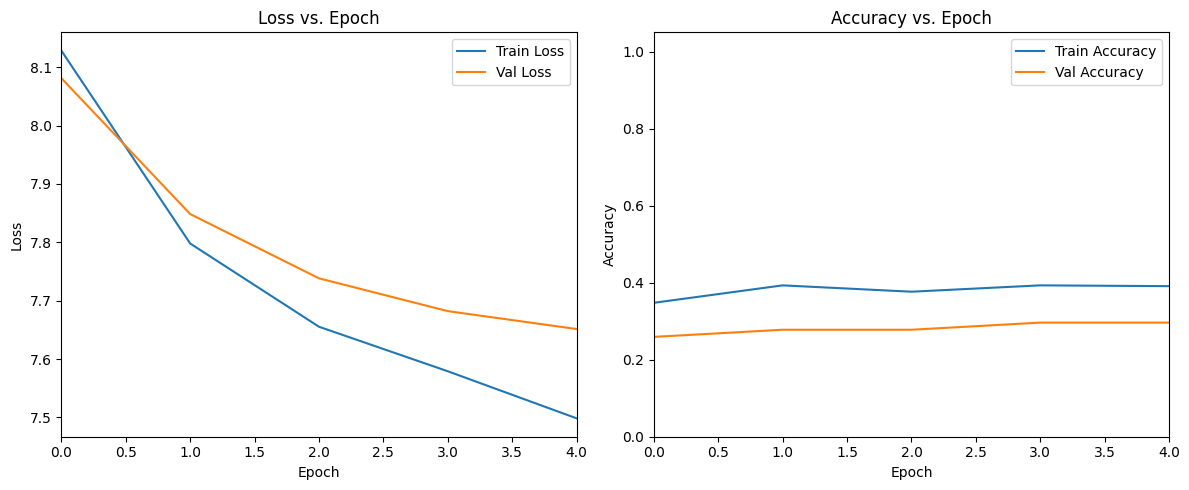


Plotting ROC Curves


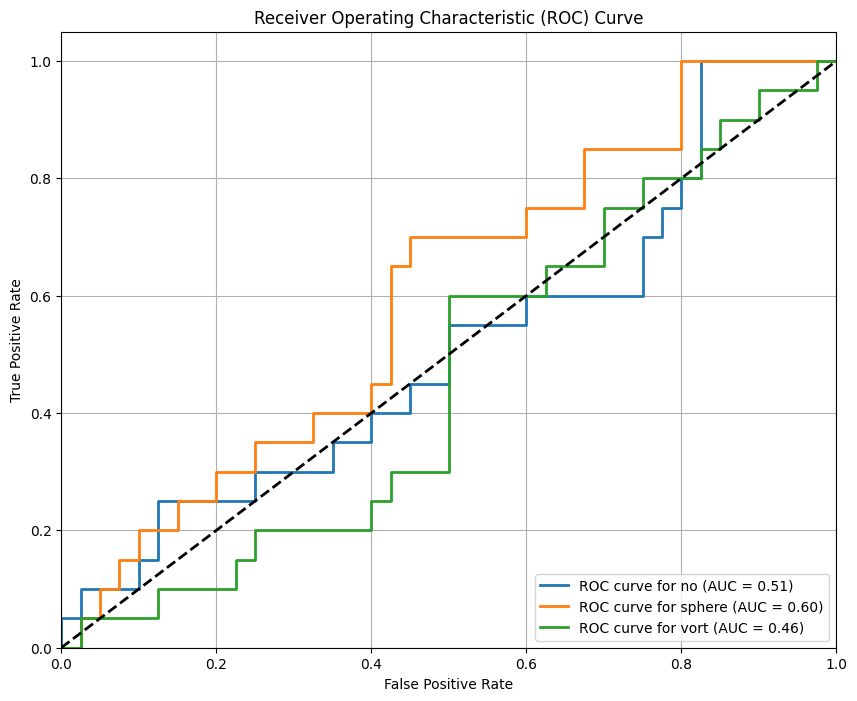


Plotting Confusion Matrix


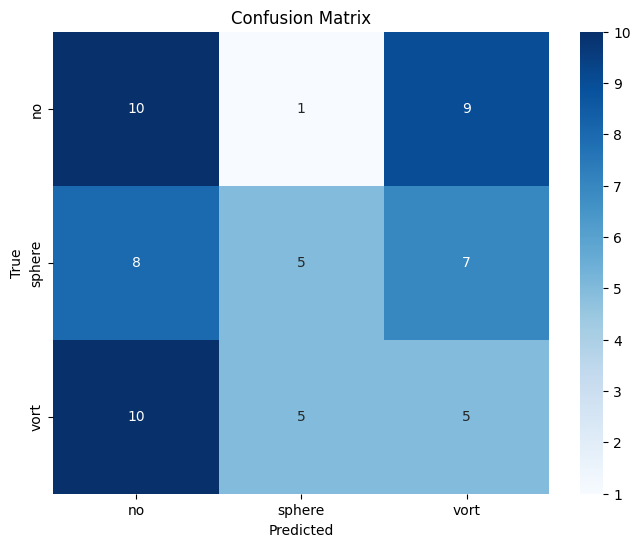

In [51]:
print("Evaluating AuxPINN Model")
test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc = evaluate_pinn_model(
    model=trained_auxpinn_model,
    test_dataloader=test_dataloader,
    criterion=criterion_head2,
    device=device
)

print("\nPlotting Training results")
plot_results(results, save_path='pinn_results.png')

print("\nPlotting ROC Curves")
plot_roc_curves(fpr, tpr, roc_auc, class_names, save_path='pinn_roc.png')

print("\nPlotting Confusion Matrix")
plot_confusion_matrix(cm, class_names, save_path='pinn_cm.png')
